# Volumetric Noise Analysis

## Import & Config

In [1]:
import ast
import math

from collections.abc import Sequence
from pathlib import Path
from typing import Any

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import skimage


from numpy.typing import NDArray
from scipy.ndimage import gaussian_filter1d, map_coordinates

import sys

sys.path.insert(0, str(Path.cwd().parent))

from cfg_data import AnalysisBase
from metal import estimate_metal_threshold, extract_metal_mask
from noise import estimate_volume_slice_stats, _em_fit_from_histogram
from utils import estimate_grayscale_range, identify_cylindrical_support
from enhance import softmax_projection


def set_slice_levels(slice_step: int, vol_shape: tuple) -> Sequence[int]:
    "Utility for setting the slice levels for noise analysis in a volume"
    slice_levels: list[int] = []
    z0 = 0
    z1 = vol_shape[0] - 1
    for n in range(z0, z1 + 1, slice_step):
        slice_levels.append(n)
    if slice_levels[-1] != z1:
        slice_levels.append(z1)

    return slice_levels


def upsample(x: NDArray, y: NDArray) -> tuple[NDArray]:
    """
    Upsamples the array y to include all integer values between the min and max of the x-array.

    Args:
        x (NDArray): The sampling grid for the array y
        y (NDArray): The array to be upsampled

    Returns:
        NDArray: The upsampled array containing all integer values between the min and max of x
    """
    all_x = np.arange(x.min(), x.max() + 1, dtype=np.float32)
    return all_x, np.interp(all_x, x, y)


plt.style.use("dark_background")
cfg_path = Path.cwd().parent / "config.toml"
data_path = Path("../Data/noise_estimates.csv")

### Load the noise data from disk

In [3]:
data_columns = [
    "volume_name",
    "slice_step",
    "slice_indexes",
    "sigma_diff",
    "sigma_corrected",
    "rho1",
    "rho2",
]


def create_empty_dictionary() -> dict[str, Any]:
    data: dict[str, Any] = {}
    for c in data_columns:
        data[c] = []
    return data


def array_columns() -> list[str]:
    return data_columns[2:]


def create_empty_dataframe() -> pd.DataFrame:
    return pd.DataFrame(create_empty_dictionary())


if not data_path.exists():
    df_data = pd.DataFrame(create_empty_dataframe())
    pd.DataFrame.to_csv(df_data, data_path, index=False)
else:
    df_data = pd.read_csv(
        data_path,
        converters={column: ast.literal_eval for column in array_columns()},
    )

delete_volumes = ["M50L-06"]
if len(delete_volumes) > 0:
    in_len = len(df_data)
    df_data = df_data[~df_data["volume_name"].isin(delete_volumes)]
    out_len = len(df_data)
    print(f"Deleted {in_len - out_len} rows corresponding to volumes: {delete_volumes}")
    pd.DataFrame.to_csv(df_data, data_path, index=False)

Deleted 0 rows corresponding to volumes: ['M50L-06']


# Load a volume

In [4]:
contrast_adjusted = True
vol_idx = 0
volume = AnalysisBase(cfg_path=cfg_path, vol_index=vol_idx, exp_index=0)
volume_name = volume.cell_name
volume_in_db = volume_name in df_data["volume_name"].values
print(f"Loaded volume {volume_name}  in_db: {volume_in_db}")


Loaded volume M50L-06  in_db: False


## Run complete noise analysis over the volume

We are now seeing structural differences in the noise as plotted over z. Whereas before we were seeing a fairly uniform value over the z-profile, there is now significant variation as a function of z.

**???**

In [ ]:
vol = volume
metal_threshold = vol.metal_threshold

# Hack for uncropped 8-bit Nikon volumes
'''metal_threshold = 150  # vol.metal_threshold
vol.z_min = 194
vol.z_max = 4072'''
#

metal_margin = vol.metal_grayscale_margin
min_area = vol.metal_min_area
trunc_k = vol.noise_clip_scale
slice_step = vol.noise_slice_step
slice_levels = set_slice_levels(slice_step, vol.vol_for_analysis.shape)

In [7]:
noise_results = estimate_volume_slice_stats(
    volume=vol.vol_for_analysis,
    slice_levels=slice_levels,
    metal_threshold=metal_threshold,
    grayscale_metal_margin=metal_margin,
    min_area=min_area,
    trunc_k=trunc_k,
)

In [8]:
slice_stats = noise_results["slice_stats"]
vol.cell_name

'M50L-06'

In [9]:
# Add the data to the DB
if not volume_in_db:
    data_row = create_empty_dictionary()
    data_row["volume_name"] = volume.cell_name
    data_row["slice_step"] = slice_step

    slice_indexes = list(slice_stats.keys())
    data_row["slice_indexes"] = tuple(slice_indexes)

    slice_idxs = slice_indexes
    sigma_corrected = [slice_stats[k]["sigma_corrected"] for k in slice_idxs]
    data_row["sigma_corrected"] = tuple(sigma_corrected)

    sigma_diff = [slice_stats[k]["sigma_diff"] for k in slice_idxs]
    data_row["sigma_diff"] = tuple(sigma_diff)

    rho_1 = [slice_stats[k]["rho1"] for k in slice_idxs]
    data_row["rho1"] = tuple(rho_1)

    rho_2 = [slice_stats[k]["rho2"] for k in slice_idxs]
    data_row["rho2"] = tuple(rho_2)

    df_row = pd.DataFrame([data_row])
    print(f"Appending data for volume: {volume.cell_name}")

    # Append the new row to the main dataframe and update
    df_data = pd.concat([df_data, df_row], ignore_index=True)
    pd.DataFrame.to_csv(df_data, data_path, index=False)
    volume_in_db = True
else:
    print(f"Volume already in DB: {volume.cell_name}")


Appending data for volume: M50L-06


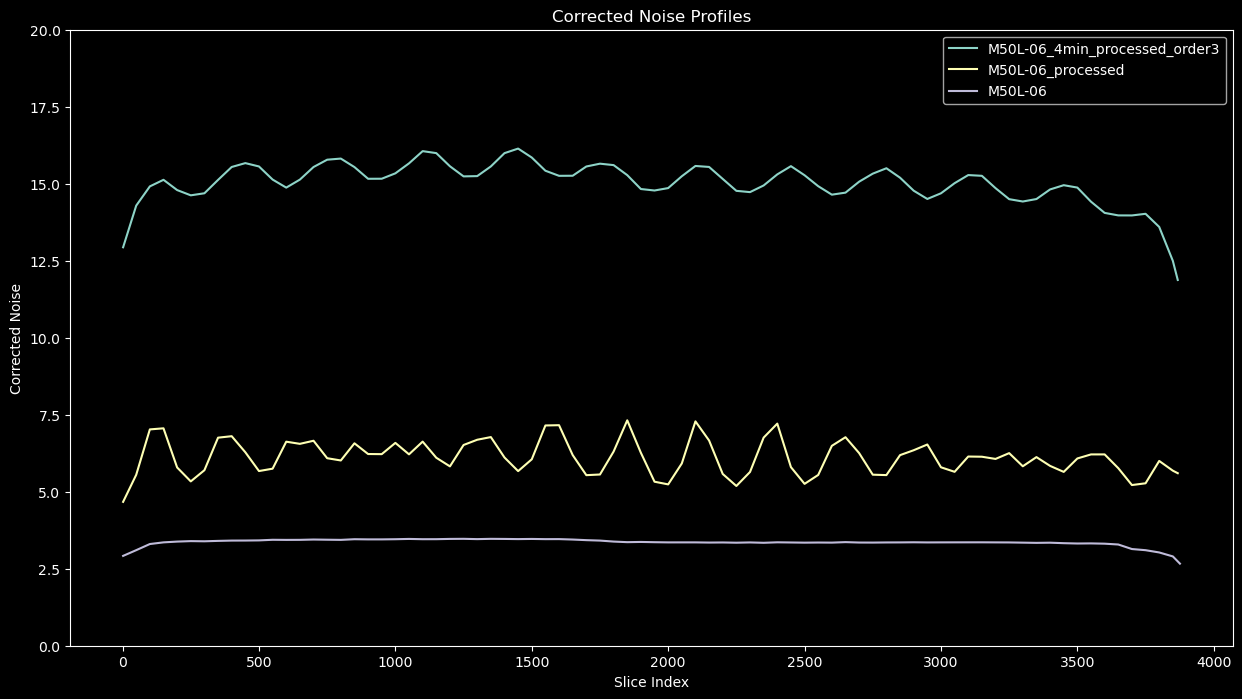

In [10]:
# Plot the corrected noise profiles for each row in the dataframe
plt.figure(figsize=(15, 8))
for index, row in df_data.iterrows():
    volume_name = row["volume_name"]
    if (
        "order0" in volume_name
        or "affine" in volume_name
        or "order1" in volume_name
        or "-06" not in volume_name
    ):
        continue
    plt.plot(
        row["slice_indexes"], row["sigma_corrected"], label=f"{row['volume_name']}"
    )

plt.xlabel("Slice Index")
plt.ylabel("Corrected Noise")
plt.ylim(bottom=0, top=20)
plt.title("Corrected Noise Profiles")
plt.legend()
plt.show()

In [ ]:
# Plot the corrected noise profiles for each row in the dataframe
plt.figure(figsize=(15, 8))
original_scale = 1.0
new_scale = original_scale
sigma = slice_step * new_scale / (2 * np.sqrt(np.log(4)))

for n, (index, row) in enumerate(df_data.iterrows()):
    volume_name = row["volume_name"]
    if (
        "order0" in volume_name or "affine" in volume_name
    ):  # or ('order5' not in volume_name):
        continue
    upsampled_x, upsampled_y = upsample(
        np.array(row["slice_indexes"]), np.array(row["sigma_corrected"])
    )
    filtered = scipy.ndimage.gaussian_filter1d(upsampled_y, sigma)
    plt.plot(upsampled_x, filtered, label=f"{row['volume_name']}")
    # plt.plot(row["slice_indexes"], row["sigma_corrected"], label=f"{row['volume_name']} (original)")
    # break

plt.xlabel("Slice Index")
plt.ylabel("Corrected Noise")
plt.ylim(bottom=3, top=12)
plt.title("Corrected Noise Profiles")
plt.legend()
plt.show()

# END of NOTEBOOK

In [ ]:
import time


def chunked_histogram(
    volume,
    start=0,
    end=None,
    bins=None,
    value_range=None,
    slice_step=100,
    stride=2,
    bin_precision=1.0,
):
    """Build a histogram from z-sampled, spatially strided volume slices."""

    t_begin = time.time()
    start, end, _ = slice(start, end).indices(volume.shape[0])
    if slice_step <= 0:
        raise ValueError("slice_step must be positive")
    if stride <= 0:
        raise ValueError("stride must be positive")

    # Sample one z-plane every slice_step and subsample each plane in x and y.
    data = np.asarray(volume[start:end:slice_step, ::stride, ::stride]).ravel()
    if data.size == 0:
        raise ValueError("The selected range does not contain any sampled slices")

    t_end = time.time()
    print(f"Data extraction time: {t_end - t_begin:.3f} seconds")

    t_begin = t_end
    if value_range is None:
        value_range = (
            np.percentile(data, 0.5),
            np.percentile(data, 99.5),
        )

    if bins is None:
        bins = math.ceil((value_range[1] - value_range[0]) / bin_precision)

    print(
        f"Value range for histogram: {value_range} computed in {time.time() - t_begin:.3f} seconds"
    )
    t_begin = time.time()
    edges = np.linspace(value_range[0], value_range[1], bins + 1)
    counts, _ = np.histogram(data, bins=edges)

    t_end = time.time()
    print(f"Histogram computation time: {t_end - t_begin:.3f} seconds")
    return counts, edges

In [ ]:
VOLUME_DIR = Path("../Data/volumes")
_32bit_vol_file = VOLUME_DIR / "M50L-06_4min.vol"
voxels_x = 1425
voxels_y = 1425
voxels_z = 4630
size_file = _32bit_vol_file.stat().st_size
print(size_file / (voxels_x * voxels_y * voxels_z * 4))
_32bit_vol = np.memmap(
    _32bit_vol_file, dtype=np.float32, mode="r", shape=(voxels_z, voxels_y, voxels_x)
)

In [ ]:
_slice_step = 50
_stride = 2
hist, edges = chunked_histogram(
    _32bit_vol,
    start=40,
    end=-40,
    slice_step=_slice_step,
    stride=_stride,
    bin_precision=0.25,
)
_max_entry_at = hist.argmax()
hist[_max_entry_at] = (hist[_max_entry_at - 1] + hist[_max_entry_at + 1]) // 2

In [ ]:
plt.plot(edges[:-1], hist)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Chunked Histogram")
plt.show()

In [ ]:
_shape = _32bit_vol.shape
_slice = _32bit_vol[_shape[0] // 2, :, :]
plt.figure(figsize=(10, 10))
plt.imshow(_slice[: _shape[1] // 2, : _shape[2] // 2], cmap="gray")
plt.colorbar()
plt.show()